
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [4]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 99.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complete!


In [3]:

# Import all the libraries we'll need
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('universal_tagset')

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.1
🚀 SpaCy version: 3.8.14



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [6]:
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

# Let's start with a classic example
sentence = "The quick brown fox jumps over the lazy dog"

# TODO: Use NLTK to tokenize and tag the sentence
# Hint: Use nltk.word_tokenize() and nltk.pos_tag()
tokens = nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?

   DT stands for Determiner, which includes words like "the" and "a." JJ stands for Adjective, which describes a noun, such as "quick," "brown," and "lazy."

2. Why do you think 'brown' and 'lazy' have the same tag?
   
   They have the same tag because both words describe nouns. "Brown" describes the fox, and "lazy" describes the dog, so they are both adjectives (JJ).

3. Can you guess what 'VBZ' represents?
   
   VBZ represents a verb in the third person singular present tense. In this sentence, "jumps" is the action performed by the fox, so it is tagged as VBZ.

*Hint: Think about the grammatical role each word plays in the sentence!*



## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [7]:

# TODO: Process the same sentence with SpaCy
# Hint: Use nlp(sentence) and access .text and .pos_ attributes
doc = nlp(sentence)

print("Original sentence:", sentence)
print("\nTokens:", [token.text for token in doc])

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's?
- Do you notice any differences in how they tag the same words?
- Which system would you prefer for a beginner? Why?

   SpaCy's tags are easier to understand because they use simple words like DET, ADJ, NOUN, and VERB. NLTK's tags are more detailed, but they are harder for beginners because they use short codes like DT, JJ, NN, and VBZ.

   They usually tag the same words in a similar way, but SpaCy gives a more general tag while NLTK gives a more specific tag. For example, NLTK tags "jumps" as VBZ, while SpaCy tags it as VERB.

   I would prefer SpaCy for a beginner because the tags are easier to read and understand. It feels more direct, while NLTK requires learning more abbreviations first.



## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [7]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I saw a bat flying at night.",      # bat = animal
    "He swung the bat very hard.",       # bat = sports equipment
    "They watch TV every evening.",      # watch = verb
    "My watch is on the table."         # watch = noun
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['bat', 'watch']:
            print(f"  🎯 '{word}' is tagged as: {tag}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


🎭 AMBIGUITY EXPLORATION

Sentence: I saw a bat flying at night.
  🎯 'bat' is tagged as: NN

Sentence: He swung the bat very hard.
  🎯 'bat' is tagged as: NN

Sentence: They watch TV every evening.
  🎯 'watch' is tagged as: VBP

Sentence: My watch is on the table.
  🎯 'watch' is tagged as: NN



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)? The computer looks at the surrounding words in the sentence to understand the meaning. This context helps it decide whether "lead" is a noun or a verb.

2. What clues in the sentence help determine the correct part of speech?
Words before and after the ambiguous word provide clues. For example, helping verbs, articles, and nearby nouns help identify the correct part of speech.

3. Can you think of other words that change meaning based on context?
Yes. Examples include "bat" (animal or sports equipment), "watch" (verb or noun), and "park" (verb or place).


**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!



## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [12]:

# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# TODO: Get tags using both Penn Treebank and Universal tagsets
# Hint: Use tagset='universal' parameter for universal tags
penn_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence))
universal_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence), tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# TODO: Print comparison table
# Hint: Zip the two tag lists together
for (word, penn_tag), (_, univ_tag) in zip(penn_tags, universal_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")


# Let's also visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler?

   The Penn Treebank tag set is more detailed because it has many specific tags. The Universal tag set is simpler because it groups words into broader categories like NOUN, VERB, and ADJ.

2. When might you want detailed tags vs. simple tags?

   Detailed tags are useful for language research or advanced NLP tasks where more information is needed. Simple tags are better for basic text analysis and when you want results that are easier to understand.

3. If you were building a search engine, which would you choose? Why?

   I would choose the Universal tag set because it is simpler and easier to work with. It provides enough information to understand the text while keeping the system efficient.
---



---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [14]:

# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is sooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

# TODO: Process each messy text sample
# 1. Use both NLTK and SpaCy
# 2. Count how many words each tagger fails to recognize properly
# 3. Identify problematic words (slang, contractions, etc.)

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # TODO: SpaCy processing
    spacy_doc = nlp(text)
    spacy_tags = [(token.text, token.pos_) for token in spacy_doc]

    # TODO: Find problematic words (tagged as 'X' or unknown)
    problematic_nltk = [
        word for word, tag in nltk_tags
        if tag in ['FW', 'UH'] or word.lower() in ['um', 'uh', 'gonna', 'ain', 'sooo', 'rn', 'smh', 'yall', "y'all", 'cuz', 'bout', 'fr', 'idk', 'tbh']
    ]
    problematic_spacy = [
        word for word, tag in spacy_tags
        if tag == 'X' or word.lower() in ['um', 'uh', 'gonna', 'ain', 'sooo', 'rn', 'smh', 'yall', "y'all", 'cuz', 'bout', 'fr', 'idk', 'tbh']
    ]

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # TODO: Calculate success rate
    nltk_success_rate = (len(nltk_tokens) - len(problematic_nltk)) / len(nltk_tokens)
    spacy_success_rate =  (len(spacy_doc) - len(problematic_spacy)) / len(spacy_doc)

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")


🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
NLTK problematic words: ['Um', 'uh']
SpaCy problematic words: ['Um', 'uh']
NLTK success rate: 91.7%
SpaCy success rate: 91.7%

📝 Sample 2: OMG this app is sooo buggy rn 😤 cant even login smh
----------------------------------------
NLTK problematic words: ['sooo', 'rn', 'smh']
SpaCy problematic words: ['sooo', 'rn', 'smh']
NLTK success rate: 75.0%
SpaCy success rate: 76.9%

📝 Sample 3: Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working
----------------------------------------
NLTK problematic words: ['Yeah', 'um']
SpaCy problematic words: ['um']
NLTK success rate: 93.1%
SpaCy success rate: 96.6%

📝 Sample 4: Y'all better fix this ASAP cuz I'm bout to switch providers fr fr
----------------------------------------
NLTK problematic words


### 🎯 Analysis Questions:
1. Which tagger handles informal language better?
   
   SpaCy handles informal language better because it is more effective at recognizing modern words, slang, and contractions.

2. What types of words cause the most problems?
   
   Slang, abbreviations, emojis, misspelled words, contractions, and internet terms like "idk," "tbh," and "rn" cause the most problems.

3. How might you preprocess text to improve tagging accuracy?

   I would remove extra punctuation, correct spelling mistakes, expand contractions, normalize slang, and convert text to a consistent format before tagging.

4. What are the implications for real-world applications?

   Better preprocessing leads to more accurate POS tagging, which improves applications such as chatbots, search engines, sentiment analysis, and customer service systems.



## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [17]:
# Define keywords for analysis
problem_keywords = ['issue', 'problem', 'error', 'bug', 'down', 'crashes', 'charged', 'locked', 'confused']
positive_keywords = ['love', 'great', 'good', 'excellent', 'happy', 'resolved', 'fixed', 'smooth']
negative_keywords = ['frustrated', 'unacceptable', 'buggy', 'crashes', 'ridiculous', 'terrible', 'slow', 'bad', 'down', 'locked', 'charged', 'confused']
urgency_indicators = ['immediately', 'asap', 'urgent', 'now', 'quickly']

# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# TODO: Analyze each transcript for:
# 1. Emotional language (adjectives that indicate sentiment)
# 2. Action words (verbs that indicate what customer wants)
# 3. Problem indicators (nouns related to issues)

analysis_results = []

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # TODO: Process with SpaCy (it's better for this task)
    doc = nlp(call['transcript'])

    # TODO: Extract different types of words
    emotional_adjectives =[
        token.text for token in doc
        if token.pos == 'ADJ' and token.text.lower() in negative_keywords + positive_keywords
    ]
    action_verbs = [
        token.text for token in doc
        if token.pos_ == 'VERB'
    ]
    problem_nouns = [
        token.text for token in doc
        if token.pos_ == 'NOUN' and token.text.lower() in problem_keywords
    ]

    # TODO: Calculate sentiment indicators
    positive_words = [
        token.text for token in doc
        if token.text.lower() in positive_keywords
    ]
    negative_words =[
        token.text for token in doc
        if token.text.lower() in negative_keywords
    ]

    # Urgency indicators count
    num_urgency_indicators = sum(1 for token in doc if token.text.lower() in urgency_indicators)

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': emotional_adjectives,
        'action_verbs': action_verbs,
        'problem_nouns': problem_nouns,
        'sentiment_score': len(positive_words) - len(negative_words),
        'urgency_indicators': num_urgency_indicators
    }

    analysis_results.append(result)

    print(f"Emotional adjectives: {emotional_adjectives}")
    print(f"Action verbs: {action_verbs}")
    print(f"Problem nouns: {problem_nouns}")
    print(f"Sentiment score: {result['sentiment_score']}")
    print(f"Urgency indicators: {result['urgency_indicators']}")


🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives: []
Action verbs: ['locked', 'access', 'trying', 'works']
Problem nouns: []
Sentiment score: -3
Urgency indicators: 0

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives: []
Action verbs: ['love', 'having', 'crashes', 'try', 'upload', 'help', 'fix']
Problem nouns: ['issue']
Sentiment score: 0
Urgency indicators: 0

🎧 Analyzing CALL_003
Category: billing
Transcript: Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and 

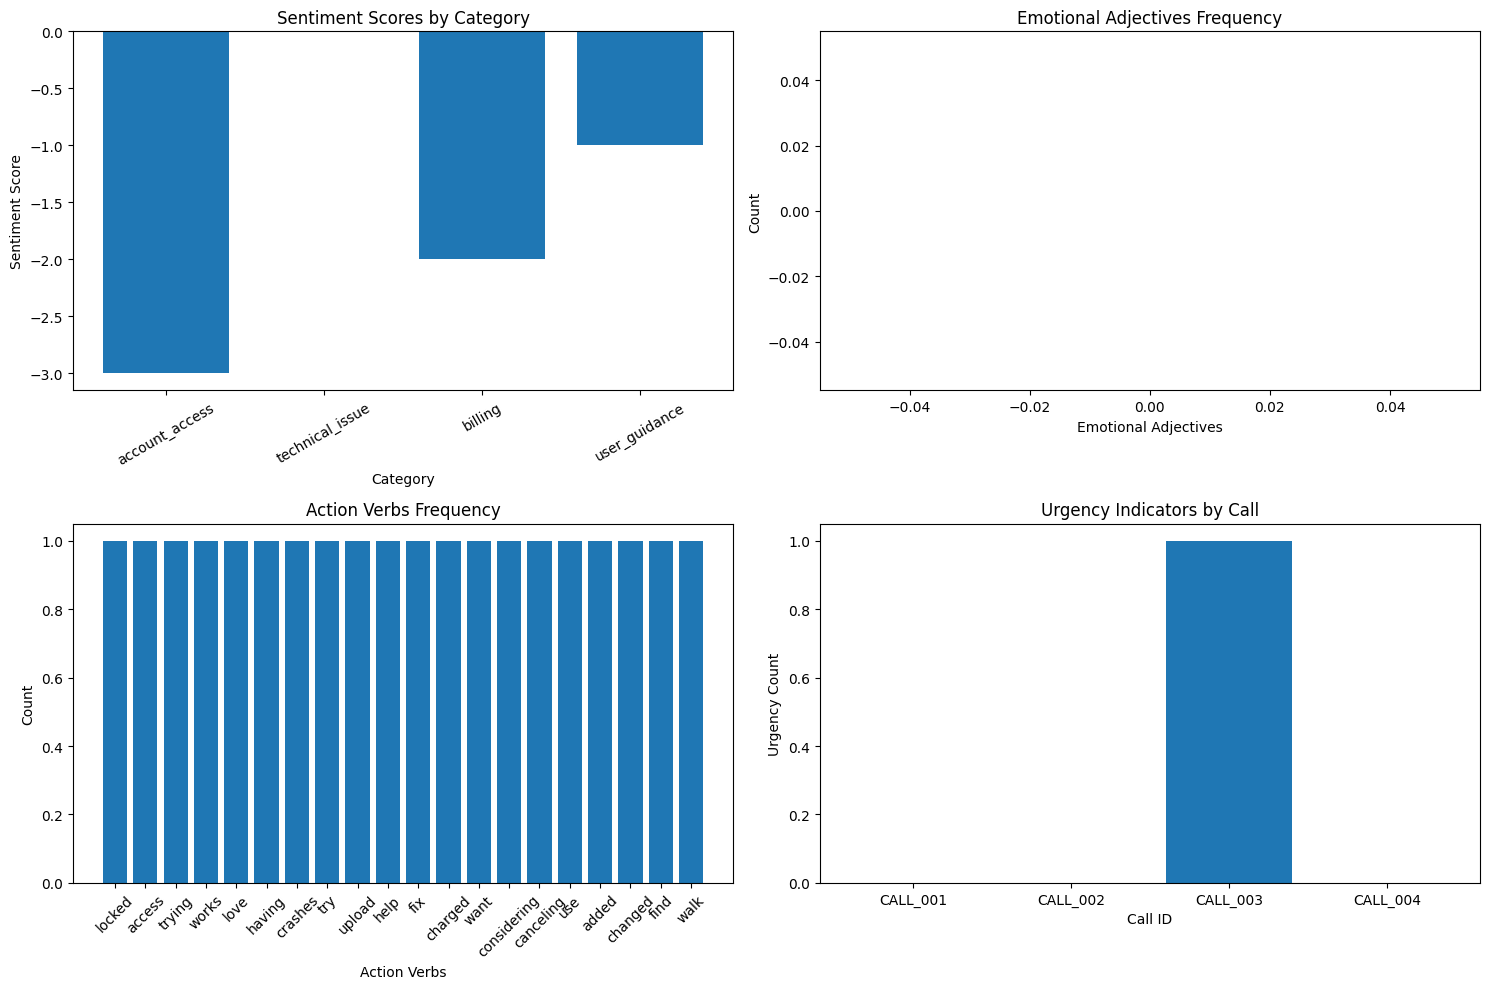

In [18]:

# Create a summary visualization
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Convert results to DataFrame
df = pd.DataFrame(analysis_results)

# Prepare word counts
all_adjectives = []
all_verbs = []

for result in analysis_results:
    all_adjectives.extend(result['emotional_adjectives'])
    all_verbs.extend(result['action_verbs'])

adjective_counts = Counter(all_adjectives)
verb_counts = Counter(all_verbs)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1 - Sentiment by category
axes[0, 0].bar(df['category'], df['sentiment_score'])
axes[0, 0].set_title('Sentiment Scores by Category')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Sentiment Score')
axes[0, 0].tick_params(axis='x', rotation=30)

# Plot 2 - Most common emotional adjectives
axes[0, 1].bar(adjective_counts.keys(), adjective_counts.values())
axes[0, 1].set_title('Emotional Adjectives Frequency')
axes[0, 1].set_xlabel('Emotional Adjectives')
axes[0, 1].set_ylabel('Count')

# Plot 3 - Action verbs frequency
axes[1, 0].bar(verb_counts.keys(), verb_counts.values())
axes[1, 0].set_title('Action Verbs Frequency')
axes[1, 0].set_xlabel('Action Verbs')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4 - Urgency analysis
axes[1, 1].bar(df['call_id'], df['urgency_indicators'])
axes[1, 1].set_title('Urgency Indicators by Call')
axes[1, 1].set_xlabel('Call ID')
axes[1, 1].set_ylabel('Urgency Count')

plt.tight_layout()
plt.show()



### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?
  This analysis can identify customers with urgent or negative issues first. Tickets with words like "frustrated," "unacceptable," or "immediately" can be given higher priority.

2. What patterns do you notice in different problem categories?

  Billing calls often contain urgent and negative words. Technical issues usually include words about apps or systems, while user guidance calls contain words about learning or finding features.

3. How might you automate the routing of calls based on POS analysis?
   
   The system can detect important nouns and action verbs to identify the type of problem. It can then automatically send billing issues to the billing team, technical problems to IT support, and account issues to customer service.

4. What are the limitations of this approach?

   POS tagging does not always understand the full meaning of a sentence. It may misinterpret slang, sarcasm, or unusual wording, so it should be combined with other NLP techniques for better accuracy.



## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.



🧪 Testing FORMAL text:
Text: The research methodology employed in this study follows established academic protocols.
------------------------------------------------------------
NLTK Penn time: 0.0034s
NLTK Univ time: 0.0005s
SpaCy time: 0.0331s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing INFORMAL text:
Text: lol this study is kinda weird but whatever works i guess 🤷‍♀️
------------------------------------------------------------
NLTK Penn time: 0.0032s
NLTK Univ time: 0.0007s
SpaCy time: 0.0104s
NLTK unknown words: 4
SpaCy unknown words: 3

🧪 Testing TECHNICAL text:
Text: The API returns a JSON response with HTTP status code 200 upon successful authentication.
------------------------------------------------------------
NLTK Penn time: 0.0023s
NLTK Univ time: 0.0006s
SpaCy time: 0.0097s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing CONVERSATIONAL text:
Text: So like, when you click that button thingy, it should totally work, right?
------------------------------

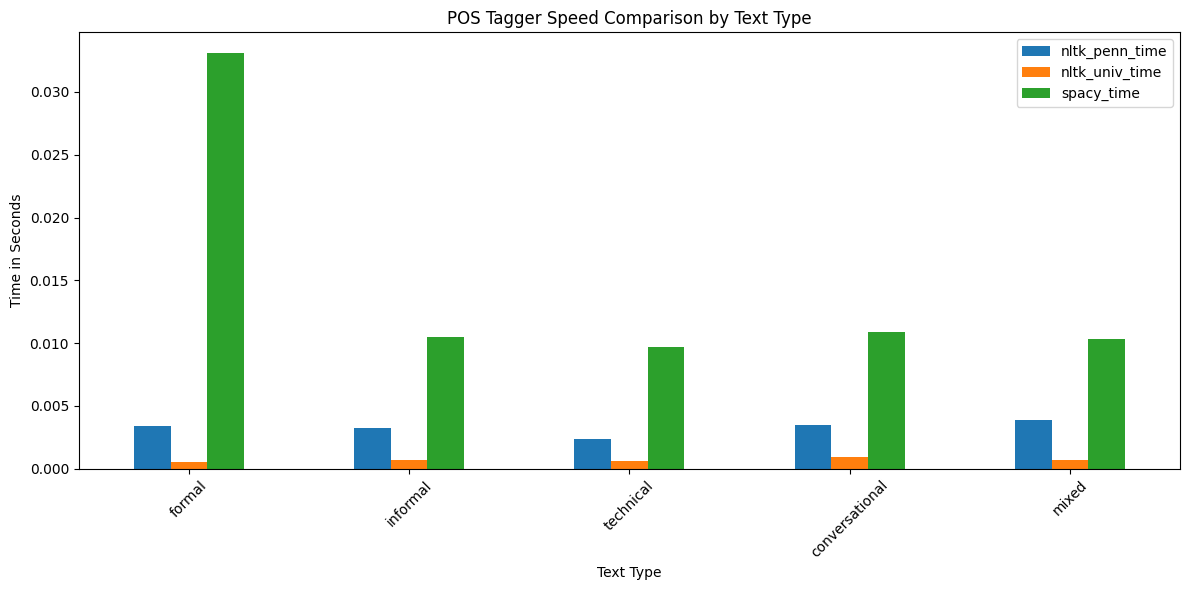

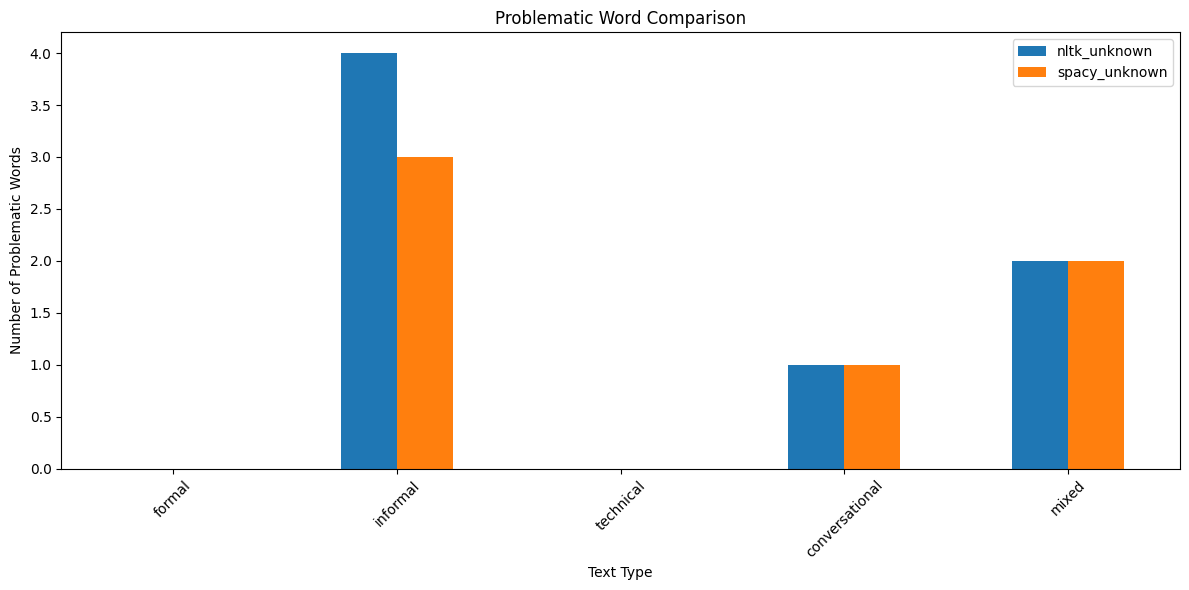

In [19]:

import time
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess 🤷‍♀️",
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

benchmark_results = defaultdict(list)

problem_words = ['lol', 'kinda', 'whatever', '🤷‍♀️', 'omg', 'wtf', 'thingy']

for text_type, text in test_texts.items():
    print(f"\n🧪 Testing {text_type.upper()} text:")
    print(f"Text: {text}")
    print("-" * 60)

    # NLTK Penn Treebank timing
    start_time = time.time()
    nltk_tokens = nltk.word_tokenize(text)
    nltk_penn_tags = nltk.pos_tag(nltk_tokens)
    nltk_penn_time = time.time() - start_time

    # NLTK Universal timing
    start_time = time.time()
    nltk_univ_tags = nltk.pos_tag(nltk_tokens, tagset='universal')
    nltk_univ_time = time.time() - start_time

    # SpaCy timing
    start_time = time.time()
    spacy_doc = nlp(text)
    spacy_time = time.time() - start_time

    # Count unknown/problematic tags
    nltk_unknown = len([
        word for word, tag in nltk_penn_tags
        if tag in ['FW', 'UH'] or word.lower() in problem_words
    ])

    spacy_unknown = len([
        token.text for token in spacy_doc
        if token.pos_ == 'X' or token.text.lower() in problem_words
    ])

    benchmark_results[text_type] = {
        'nltk_penn_time': nltk_penn_time,
        'nltk_univ_time': nltk_univ_time,
        'spacy_time': spacy_time,
        'nltk_unknown': nltk_unknown,
        'spacy_unknown': spacy_unknown
    }

    print(f"NLTK Penn time: {nltk_penn_time:.4f}s")
    print(f"NLTK Univ time: {nltk_univ_time:.4f}s")
    print(f"SpaCy time: {spacy_time:.4f}s")
    print(f"NLTK unknown words: {nltk_unknown}")
    print(f"SpaCy unknown words: {spacy_unknown}")

# Create performance comparison visualization
benchmark_df = pd.DataFrame(benchmark_results).T

benchmark_df[['nltk_penn_time', 'nltk_univ_time', 'spacy_time']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('POS Tagger Speed Comparison by Text Type')
plt.xlabel('Text Type')
plt.ylabel('Time in Seconds')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

benchmark_df[['nltk_unknown', 'spacy_unknown']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Problematic Word Comparison')
plt.xlabel('Text Type')
plt.ylabel('Number of Problematic Words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?
  SpaCy is the fastest tagger. Speed is important when processing a large number of documents or real-time applications like chatbots and search engines.

2. Which handles informal text best?
   
   SpaCy handles informal text better because it performs well with slang, contractions, and modern language.

3. How do the taggers compare on technical jargon?

   Both taggers can recognize many technical terms, but SpaCy generally handles technical text more consistently. NLTK may assign more detailed tags, while SpaCy provides simpler and easier-to-understand tags.

4. What trade-offs do you see between speed and accuracy?
   
   SpaCy is faster and works well for most real-world tasks. NLTK provides more detailed tagging but can be slower. The best choice depends on whether speed or detailed analysis is more important.



## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [20]:

# Challenging edge cases
edge_cases = [ "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.", # Famous ambiguous sentence
              "Time flies like an arrow; fruit flies like a banana.", # Classic ambiguity
               "The man the boat the river.", # Garden path sentence
               "Police police Police police police police Police police.", # Recursive structure
               "James while John had had had had had had had had had had had a better effect on the teacher.", # Had had had...
               "Can can can can can can can can can can.", # Modal/noun ambiguity
               "@username #hashtag http://bit.ly/abc123 😂🔥💯", # Social media elements
               "COVID-19 AI/ML IoT APIs RESTful microservices", # Modern technical terms
              ]

print("🚨 EDGE CASE ANALYSIS")
print("=" * 50)

for i, text in enumerate(edge_cases, 1):
    print(f"\n🔍 Edge Case {i}:")
    print(f"Text: {text}")
    print("-" * 30)

    try:
        # Process with both taggers
        nltk_tokens = nltk.word_tokenize(text)
        nltk_tags = nltk.pos_tag(nltk_tokens)
        spacy_doc = nlp(text)

        print("NLTK tags:", [(w, t) for w, t in nltk_tags])
        print("SpaCy tags:", [(token.text, token.pos_) for token in spacy_doc])

        # Analyze possible problems
        nltk_problem_words = [
            word for word, tag in nltk_tags
            if tag in ['FW', 'UH'] or word.startswith('@') or word.startswith('#') or 'http' in word
        ]

        spacy_problem_words = [
            token.text for token in spacy_doc
            if token.pos_ == 'X' or token.text.startswith('@') or token.text.startswith('#') or 'http' in token.text
        ]

        if nltk_problem_words or spacy_problem_words:
            print("Possible problematic words:")
            print("NLTK:", nltk_problem_words)
            print("SpaCy:", spacy_problem_words)
        else:
            print("No major problematic words detected, but the sentence may still be grammatically confusing.")

    except Exception as e:
        print(f"❌ Error processing: {e}")

print("\n🤔 REFLECTION ON LIMITATIONS:")
print("=" * 40)
print("POS taggers can struggle with repeated words, ambiguous sentences, social media text, emojis, hashtags, URLs, and new technical terms.")
print("They depend heavily on context, but some sentences are confusing even for humans.")
print("This shows that POS tagging is useful, but it is not perfect and should be combined with other NLP methods for real-world applications.")


🚨 EDGE CASE ANALYSIS

🔍 Edge Case 1:
Text: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------
NLTK tags: [('Buffalo', 'NNP'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('.', '.')]
SpaCy tags: [('Buffalo', 'PROPN'), ('buffalo', 'NOUN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('.', 'PUNCT')]
No major problematic words detected, but the sentence may still be grammatically confusing.

🔍 Edge Case 2:
Text: Time flies like an arrow; fruit flies like a banana.
------------------------------
NLTK tags: [('Time', 'NNP'), ('flies', 'NNS'), ('like', 'IN'), ('an', 'DT'), ('arrow', 'NN'), (';', ':'), ('fruit', 'CC'), ('flies', 'NNS'), ('like', 'IN'), ('a', 'DT'), ('banana', 'NN'), ('.', '.')]
SpaCy tags: [('Time', 'NOUN'), ('flies', 'VERB'), ('like', 'ADP'), ('an', 'DET')


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. **Why do these edge cases break the taggers?**  
These edge cases confuse the taggers because they contain ambiguous words, unusual sentence structures, slang, emojis, hashtags, and technical terms. The taggers rely on context, and some of these examples are difficult even for humans to understand.

2. **How might you preprocess text to handle some of these issues?**  
I would remove or replace emojis, hashtags, and URLs, correct spelling mistakes, expand contractions, and normalize slang before running the POS tagger. This helps improve tagging accuracy.

3. **When would these limitations matter in real applications?**  
These limitations matter in applications such as chatbots, social media analysis, customer service, and voice assistants because users often write informal or ambiguous text. Incorrect tagging can lead to inaccurate results.

4. **How do modern large language models handle these cases differently?**  
Modern large language models understand context much better because they are trained on large amounts of text. They can often recognize slang, technical terms, and ambiguous sentences more accurately than traditional POS taggers.

---



## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.

2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?

3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?

4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)

5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?



### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

### 1. Tool Comparison:
I would use NLTK when I want to learn about POS tagging or need detailed grammatical tags. I would use SpaCy for real-world projects because it is faster, easier to use, and works well on large amounts of text. For production applications, I think SpaCy is the better choice.

### 2. Real-World Applications:
POS tagging could help a customer service company analyze support messages. The system could identify important nouns, verbs, and adjectives to determine the customer's problem and automatically send the ticket to the correct department. This would help reduce response time and improve customer support.

### 3. Limitations and Solutions:
One limitation is that POS taggers can struggle with slang, emojis, abbreviations, and sentences with multiple meanings. They may also have trouble with technical terms or unusual grammar. These problems can be reduced by cleaning the text before processing and combining POS tagging with more advanced NLP techniques.

### 4. Future Learning:
I would like to learn more about how large language models and neural networks perform POS tagging. I am also interested in learning how to train custom models for different industries, such as healthcare or customer service.

### 5. Integration:
POS tagging is an important step in many NLP pipelines because it helps computers understand the role of each word in a sentence. It can improve tasks such as sentiment analysis, named entity recognition, information extraction, text classification, machine translation, and chatbots.



---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
